## 0. Setup

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# Ajuste ROOT se necessário — aponta para a raiz do repositório
ROOT      = Path("C:/Users/Pedro/Projects/OSPA Place Case")
RAW       = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"

assert ROOT.exists(), f"Raiz não encontrada: {ROOT}"
assert PROCESSED.exists(), f"Pasta processed não encontrada — rode o ETL primeiro"

plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (10, 4)})
print("✅ Paths configurados")
print(f"   RAW       → {RAW}")
print(f"   PROCESSED → {PROCESSED}")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

✅ Paths configurados
   RAW       → C:\Users\Pedro\Projects\OSPA Place Case\data\raw
   PROCESSED → C:\Users\Pedro\Projects\OSPA Place Case\data\processed


In [3]:
def load_raw(
    subdir: str,
    filename: str,
    sep: str = ",",
    nrows: int | None = None
) -> pd.DataFrame:
    """
    Carrega CSV raw com detecção automática de encoding.

    :param subdir: Subpasta dentro de data/raw
    :param filename: Nome do arquivo CSV
    :param sep: Separador do CSV
    :param nrows: Limite de linhas (None = tudo)
    :return: DataFrame carregado
    """
    path = RAW / subdir / filename
    for enc in ("utf-8", "latin-1", "cp1252", "ISO-8859-1"):
        try:
            return pd.read_csv(path, dtype=str, encoding=enc,
                               sep=sep, low_memory=False, nrows=nrows)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"Não foi possível ler {path} com nenhum encoding testado")


def profile(
    df: pd.DataFrame,
    label: str
) -> None:
    """
    Exibe perfil básico de um DataFrame: shape, dtypes e % de nulos.

    :param df: DataFrame a analisar
    :param label: Rótulo para identificação
    """
    nulos = (df.isnull().mean() * 100).round(1).rename("nulos_%")
    resumo = pd.concat([df.dtypes.rename("dtype"), nulos], axis=1)
    print(f"\n{'='*55}")
    print(f"  {label}  —  shape: {df.shape}")
    print(f"{'='*55}")
    print(resumo.to_string())


def bar_top(
    series: pd.Series,
    title: str,
    n: int = 15,
    color: str = "#4C72B0"
) -> None:
    """
    Plota barras horizontais com os top-N valores de uma Series.

    :param series: Series com contagens ou valores
    :param title: Título do gráfico
    :param n: Número de barras
    :param color: Cor das barras
    """
    ax = series.head(n).sort_values().plot(
        kind="barh", title=title, color=color, edgecolor="white"
    )
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    plt.tight_layout()
    plt.show()


print("✅ Helpers definidos")

✅ Helpers definidos


---
## 1. RAW — Atividade Econômica

In [7]:
df_eco_raw = load_raw(
    "atividade_economica",
    "atividade_economica.csv",
    sep=";"
)
profile(df_eco_raw, "Atividade Econômica RAW")
df_eco_raw.head(3)


  Atividade Econômica RAW  —  shape: (564344, 22)
                               dtype  nulos_%
ID_ATIV_ECON_ESTABELECIMENTO  object      0.0
CNAE_PRINCIPAL                object      0.0
DESCRICAO_CNAE_PRINCIPAL      object      0.0
CNAE                          object      0.0
DATA_INICIO_ATIVIDADE         object      0.0
NATUREZA_JURIDICA             object      0.0
PORTE_EMPRESA                 object      0.0
AREA_UTILIZADA                object      0.0
IND_SIMPLES                   object      0.0
IND_MEI                       object      0.0
IND_POSSUI_ALVARA             object      0.0
TIPO_UNIDADE                  object      0.0
FORMA_ATUACAO                 object     12.4
DESC_LOGRADOURO               object      0.0
NOME_LOGRADOURO               object      0.0
NUMERO_IMOVEL                 object      0.0
COMPLEMENTO                   object     46.8
NOME_BAIRRO                   object      0.0
NOME                          object      0.0
NOME_FANTASIA                

,ID_ATIV_ECON_ESTABELECIMENTO,CNAE_PRINCIPAL,DESCRICAO_CNAE_PRINCIPAL,CNAE,DATA_INICIO_ATIVIDADE,NATUREZA_JURIDICA,PORTE_EMPRESA,AREA_UTILIZADA,IND_SIMPLES,IND_MEI,IND_POSSUI_ALVARA,TIPO_UNIDADE,FORMA_ATUACAO,DESC_LOGRADOURO,NOME_LOGRADOURO,NUMERO_IMOVEL,COMPLEMENTO,NOME_BAIRRO,NOME,NOME_FANTASIA,CNPJ,GEOMETRIA
0,658,4110700,INCORPORACAO DE EMPREENDIMENTOS IMOBILIARIOS,"4110700, 4120400, 4399101",04-05-1992,SOCIEDADE EMPRESÁRIA LIMITADA,EMPRESA DE PEQUENO PORTE,28,N,N,NÃO,ESCRITÓRIO ADMINSTRATIVO,NaN,RUA,JACUI,505,"SALA: 01,",COLEGIO BATISTA,CONSTRUTORA A R B LTDA,NaN,41911819000198,POINT (611748.06 7798276.46)
1,659,8030700,ATIVIDADES DE INVESTIGACAO PARTICULAR,"8030700, 8291100",01-09-1993,SOCIEDADE SIMPLES LIMITADA,MICROEMPRESA - ME,63,S,N,SIM,ESCRITÓRIO ADMINSTRATIVO,NaN,AVE,DO CONTORNO,4640,SALA 701 SALA 702,FUNCIONARIOS,A A ABA AGENCIA DE PESQUISA LTDA,LIDER INVESTIGACOES SIGILOSAS,73487613000179,POINT (612479.69 7795347.82)
2,660,6920601,ATIVIDADES DE CONTABILIDADE,6920601,12-11-1993,SOCIEDADE SIMPLES LIMITADA,EMPRESA DE PEQUENO PORTE,60,S,N,SIM,UNIDADE PRODUTIVA,ESTABELECIMENTO FIXO,RUA,DOS GUAJAJARAS,910,"SALA: 16191620 ,",CENTRO,METROPOLE INTEGRACAO CONTABIL LTDA,METROPOLE CONTABIL,73788218000126,POINT (610658.10 7796519.70)


In [5]:
# Distribuição de situação das empresas
if "SITUACAO" in df_eco_raw.columns:
    bar_top(df_eco_raw["SITUACAO"].value_counts(), "Situação das Empresas (RAW)")
else:
    print("Coluna SITUACAO não encontrada. Colunas disponíveis:", df_eco_raw.columns.tolist())

Coluna SITUACAO não encontrada. Colunas disponíveis: ['ID_ATIV_ECON_ESTABELECIMENTO', 'CNAE_PRINCIPAL', 'DESCRICAO_CNAE_PRINCIPAL', 'CNAE', 'DATA_INICIO_ATIVIDADE', 'NATUREZA_JURIDICA', 'PORTE_EMPRESA', 'AREA_UTILIZADA', 'IND_SIMPLES', 'IND_MEI', 'IND_POSSUI_ALVARA', 'TIPO_UNIDADE', 'FORMA_ATUACAO', 'DESC_LOGRADOURO', 'NOME_LOGRADOURO', 'NUMERO_IMOVEL', 'COMPLEMENTO', 'NOME_BAIRRO', 'NOME', 'NOME_FANTASIA', 'CNPJ', 'GEOMETRIA']


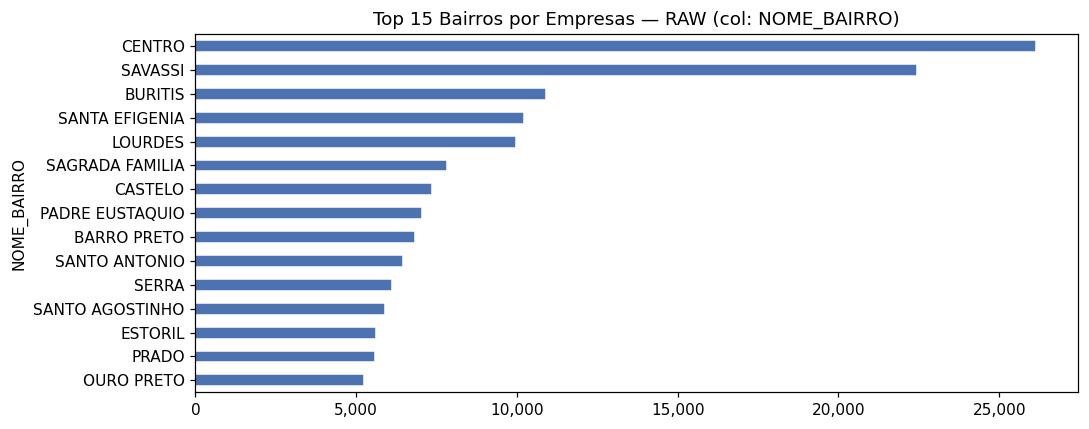

In [8]:
# Top bairros por número de registros
col_bairro_eco = next((c for c in df_eco_raw.columns if "BAIRRO" in c.upper()), None)
if col_bairro_eco:
    bar_top(
        df_eco_raw[col_bairro_eco].value_counts(),
        f"Top 15 Bairros por Empresas — RAW (col: {col_bairro_eco})"
    )
else:
    print("Coluna de bairro não encontrada. Colunas:", df_eco_raw.columns.tolist())

## 2. PROCESSED — Empresas por Bairro

In [10]:
df_eco = pd.read_parquet(PROCESSED / "empresas_por_bairro.parquet")
profile(df_eco, "empresas_por_bairro PROCESSED")
df_eco.head()

ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_eco["total_empresas"].hist(bins=40, ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribuição: Total de Empresas por Bairro")
axes[0].set_xlabel("Total de Empresas")

df_eco["diversidade_setores"].hist(bins=30, ax=axes[1], color="#55A868", edgecolor="white")
axes[1].set_title("Distribuição: Diversidade de Setores por Bairro")
axes[1].set_xlabel("Qtd de Setores Distintos")

plt.tight_layout()
plt.show()

In [ ]:
# Top 15 bairros por empresas (PROCESSED)
bar_top(
    df_eco.set_index("bairro")["total_empresas"],
    "Top 15 Bairros por Total de Empresas (PROCESSED)"
)

In [ ]:
# Setor dominante mais frequente
bar_top(
    df_eco["setor_dominante"].value_counts(),
    "Setores Dominantes mais Frequentes entre Bairros",
    color="#C44E52"
)

---
## 3. RAW — Pontos de Ônibus

In [ ]:
df_pts_raw = load_raw("pontos_onibus", "pontos_onibus.csv")
profile(df_pts_raw, "Pontos de Ônibus RAW")
df_pts_raw.head(3)

In [ ]:
# Verifica se tem coluna de bairro ou só geometria
col_bairro_pts = next((c for c in df_pts_raw.columns if "BAIRRO" in c.upper()), None)
if col_bairro_pts:
    bar_top(
        df_pts_raw[col_bairro_pts].value_counts(),
        f"Top 15 Bairros por Pontos de Ônibus — RAW (col: {col_bairro_pts})"
    )
else:
    print("Dataset não tem coluna de bairro — usa spatial join no ETL (esperado).")
    print("Colunas disponíveis:", df_pts_raw.columns.tolist())

## 4. PROCESSED — Acessibilidade por Bairro

In [ ]:
df_ace = pd.read_parquet(PROCESSED / "acessibilidade_por_bairro.parquet")
profile(df_ace, "acessibilidade_por_bairro PROCESSED")
df_ace.head()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_ace["total_pontos_onibus"].hist(bins=30, ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribuição: Pontos de Ônibus")

df_ace["total_embarques_dia"].hist(bins=30, ax=axes[1], color="#55A868", edgecolor="white")
axes[1].set_title("Distribuição: Embarques/Dia")

df_ace["indice_acessibilidade"].hist(bins=30, ax=axes[2], color="#C44E52", edgecolor="white")
axes[2].set_title("Distribuição: Índice de Acessibilidade")

plt.tight_layout()
plt.show()

In [ ]:
# Top 15 bairros por pontos de ônibus
bar_top(
    df_ace.set_index("bairro")["total_pontos_onibus"],
    "Top 15 Bairros por Pontos de Ônibus (PROCESSED)"
)

---
## 5. RAW — Qualidade Urbana (Parques e Equipamentos)

In [ ]:
df_parq_raw   = load_raw("parques", "parques.csv")
df_equip_raw  = load_raw("equipamentos_esportivos", "equipamentos_esportivos.csv")
profile(df_parq_raw, "Parques RAW")
profile(df_equip_raw, "Equipamentos Esportivos RAW")

## 6. PROCESSED — Qualidade Urbana por Bairro

In [ ]:
df_qua = pd.read_parquet(PROCESSED / "qualidade_urbana_por_bairro.parquet")
profile(df_qua, "qualidade_urbana_por_bairro PROCESSED")
df_qua.head()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_qua["total_parques"].hist(bins=20, ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribuição: Parques por Bairro")

df_qua["total_equipamentos_esportivos"].hist(bins=20, ax=axes[1], color="#55A868", edgecolor="white")
axes[1].set_title("Distribuição: Equipamentos Esportivos por Bairro")

plt.tight_layout()
plt.show()

---
## 7. RAW — Matriz O-D

In [ ]:
# Carrega só 5k linhas para não travar — dataset tem 188k registros
df_od_raw = load_raw("matriz_od", "matriz_od.csv", sep=";", nrows=5000)
profile(df_od_raw, "Matriz O-D RAW (amostra 5k)")
df_od_raw.head(3)

In [ ]:
print(f"Origens H3 únicas (amostra): {df_od_raw['H3_ORIGEM'].nunique()}")
print(f"Destinos H3 únicos (amostra): {df_od_raw['H3_DESTINO'].nunique()}")

if "TIPO_CARTAO" in df_od_raw.columns:
    bar_top(
        df_od_raw["TIPO_CARTAO"].value_counts(),
        "Distribuição por Tipo de Cartão — Matriz O-D (amostra)",
        color="#8172B2"
    )

## 8. PROCESSED — Matriz O-D Agregada

In [ ]:
df_od = pd.read_parquet(PROCESSED / "matriz_od_agregada.parquet")
profile(df_od, "matriz_od_agregada PROCESSED")
df_od.head()

In [ ]:
if len(df_od) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    df_od["total_viagens_originadas"].hist(bins=30, ax=axes[0], color="#4C72B0", edgecolor="white")
    axes[0].set_title("Distribuição: Viagens Originadas por Bairro")

    df_od["destinos_unicos"].hist(bins=30, ax=axes[1], color="#8172B2", edgecolor="white")
    axes[1].set_title("Distribuição: Destinos Únicos por Bairro")

    plt.tight_layout()
    plt.show()

    bar_top(
        df_od.set_index("bairro")["total_viagens_originadas"],
        "Top 15 Bairros por Viagens Originadas (PROCESSED)",
        color="#8172B2"
    )
else:
    print("⚠️ matriz_od_agregada.parquet está vazio — verifique o ETL da matriz O-D")

---
## 9. PROCESSED — Score Final

In [ ]:
df_score = pd.read_parquet(PROCESSED / "score_final.parquet")
profile(df_score, "score_final PROCESSED")
df_score[["ranking", "bairro", "score_final", "score_eco", "score_ace", "score_qua"]].head(15)

In [ ]:
# Distribuição do score final
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_score["score_final"].hist(bins=40, ax=axes[0], color="#DD8452", edgecolor="white")
axes[0].set_title("Distribuição do Score Final (0–100)")
axes[0].set_xlabel("Score")

df_score[["score_eco", "score_ace", "score_qua"]].plot(
    kind="hist", bins=30, alpha=0.6, ax=axes[1],
    color=["#4C72B0", "#55A868", "#C44E52"]
)
axes[1].set_title("Distribuição dos Scores por Dimensão")
axes[1].set_xlabel("Score da Dimensão")

plt.tight_layout()
plt.show()

In [ ]:
# Top 20 bairros
top20 = df_score.head(20).set_index("bairro")[["score_eco", "score_ace", "score_qua"]]

top20.plot(
    kind="barh", stacked=True, figsize=(12, 8),
    color=["#4C72B0", "#55A868", "#C44E52"],
    title="Top 20 Bairros — Composição do Score Final"
)
plt.xlabel("Score (componentes)")
plt.legend(["Econômico (40%)", "Acessibilidade (35%)", "Qualidade Urbana (25%)"])
plt.tight_layout()
plt.show()

In [ ]:
# Correlação entre dimensões
corr = df_score[["score_eco", "score_ace", "score_qua", "score_final"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=30, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=10)
ax.set_title("Correlação entre Dimensões do Score")
plt.tight_layout()
plt.show()

---
## 10. Consistência de Bairros entre Fontes PROCESSED

In [ ]:
# Quantos bairros cada fonte tem e quais estão no score final
fontes = {
    "empresas":      set(df_eco["bairro"]),
    "acessibilidade": set(df_ace["bairro"]),
    "qualidade":     set(df_qua["bairro"]),
    "matriz_od":     set(df_od["bairro"]) if len(df_od) > 0 else set(),
    "score_final":   set(df_score["bairro"]),
}

print("Bairros por fonte:")
for nome, bairros in fontes.items():
    print(f"  {nome:<20} {len(bairros):>4} bairros")

# Bairros presentes em todas as fontes com dados
fontes_com_dados = {k: v for k, v in fontes.items() if v}
intersecao = set.intersection(*fontes_com_dados.values())
print(f"\nBairros em TODAS as fontes (interseção): {len(intersecao)}")

# Bairros só no score (sem dados em nenhuma fonte individual)
bairros_sem_fonte = fontes["score_final"] - fontes["empresas"] - fontes["acessibilidade"] - fontes["qualidade"]
print(f"Bairros no score sem dados em nenhuma fonte individual: {len(bairros_sem_fonte)}")
if bairros_sem_fonte:
    print("  Exemplos:", sorted(bairros_sem_fonte)[:10])

In [ ]:
# Bairros da acessibilidade que NÃO estão nas empresas — candidatos a problemas de join
so_ace = fontes["acessibilidade"] - fontes["empresas"]
so_eco = fontes["empresas"] - fontes["acessibilidade"]

print(f"Bairros só em acessibilidade (não em empresas): {len(so_ace)}")
print(f"Bairros só em empresas (não em acessibilidade): {len(so_eco)}")
print("\nExemplos bairros só em acessibilidade:", sorted(so_ace)[:8])
print("Exemplos bairros só em empresas:",       sorted(so_eco)[:8])